# Bildklassifikation für Qualitätskontrolle im Agrarbereich
## Vision Transformer (ViT) – Pretrained vs. From Scratch
### PyTorch + HuggingFace 




```

## 0. Pakete installieren (einmalig)

In [1]:
import subprocess, sys

packages = ["torch", "torchvision", "transformers", "timm", "scikit-learn", "matplotlib", "Pillow"]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "--quiet"], check=True)
    print(f"✅ {pkg} installiert")

print("\n✅ Alle Pakete installiert – bitte Kernel neu starten! (Kernel → Restart Kernel)")

✅ torch installiert
✅ torchvision installiert
✅ transformers installiert
✅ timm installiert
✅ scikit-learn installiert
✅ matplotlib installiert
✅ Pillow installiert

✅ Alle Pakete installiert – bitte Kernel neu starten! (Kernel → Restart Kernel)


## 1. Imports & Konfiguration

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from transformers import ViTForImageClassification, ViTConfig

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from copy import deepcopy

# ── Device Setup ───────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch Version:    ", torch.__version__)
print("Device:             ", DEVICE)
if torch.cuda.is_available():
    print("GPU:                ", torch.cuda.get_device_name(0))

c:\Users\Hendrik\Documents\GitHub\apple_quality_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version:     2.12.1+cpu
Device:              cpu


In [3]:
# ── Konfiguration ──────────────────────────────────────────────────────────────
DATA_DIR   = Path("../../data/Apple_Data_bereinigt")
IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 42
NUM_WORKERS= 0    # Windows: 0 (verhindert multiprocessing-Fehler)

torch.manual_seed(SEED)
np.random.seed(SEED)

# Pretrained ViT
PT_EPOCHS_HEAD    = 5
PT_EPOCHS_FINETUNE= 5
PT_LR_HEAD        = 1e-3
PT_LR_FINETUNE    = 1e-5
PT_MODEL_PATH     = "best_vit_pretrained.pth"

# ViT From Scratch
SC_EPOCHS         = 30
SC_LR             = 1e-3
SC_MODEL_PATH     = "best_vit_scratch.pth"

# ViT-B/16 Architektur (From Scratch)
PATCH_SIZE        = 16
PROJECTION_DIM    = 768
NUM_HEADS         = 12
NUM_LAYERS        = 12
MLP_DIM           = 3072
DROPOUT           = 0.1

## 2. Dataset laden & aufteilen (70 / 15 / 15)

PyTorch nutzt `torchvision.transforms` statt Keras-Augmentation –  
die Logik ist identisch.

In [4]:
# ── Transforms (Augmentation nur für Training) ────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet Mittelwert
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Dataset laden ──────────────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names  = full_dataset.classes
num_classes  = len(class_names)

print("Klassen:        ", class_names)
print("Anzahl Klassen: ", num_classes)
print("Gesamtbilder:   ", len(full_dataset))

# 70 / 15 / 15 Split
total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_idx, val_idx, test_idx = random_split(
    range(total), [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Eigene Subset-Klasse um unterschiedliche Transforms anzuwenden
from torch.utils.data import Subset

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = list(indices)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        # img ist noch PIL Image (kein Transform im vollen Dataset)
        return self.transform(img), label

# PIL-Images → full_dataset ohne Transform
full_dataset_pil = datasets.ImageFolder(root=DATA_DIR, transform=None)

train_ds = TransformSubset(full_dataset_pil, train_idx, train_transform)
val_ds   = TransformSubset(full_dataset_pil, val_idx,   val_transform)
test_ds  = TransformSubset(full_dataset_pil, test_idx,  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Training:   {len(train_ds)} Bilder ({len(train_loader)} Batches)")
print(f"Validation: {len(val_ds)} Bilder ({len(val_loader)} Batches)")
print(f"Test:       {len(test_ds)} Bilder ({len(test_loader)} Batches)")

Klassen:         ['Apple__Healthy', 'Apple__Rotten']
Anzahl Klassen:  2
Gesamtbilder:    4751
Training:   3325 Bilder (104 Batches)
Validation: 712 Bilder (23 Batches)
Test:       714 Bilder (23 Batches)


## 3. Augmentation Vorschau

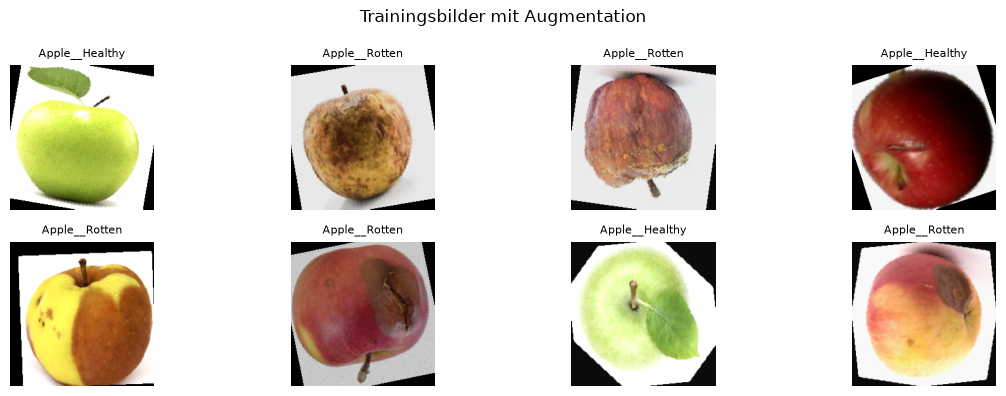

In [5]:
def denormalize(tensor):
    """Normalisierung rückgängig machen für Visualisierung."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 4))
for i in range(min(8, len(images))):
    ax = plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(class_names[labels[i]], fontsize=8)
    plt.axis("off")
plt.suptitle("Trainingsbilder mit Augmentation")
plt.tight_layout(); plt.show()

## 4. ViT Architektur – Patch Visualisierung

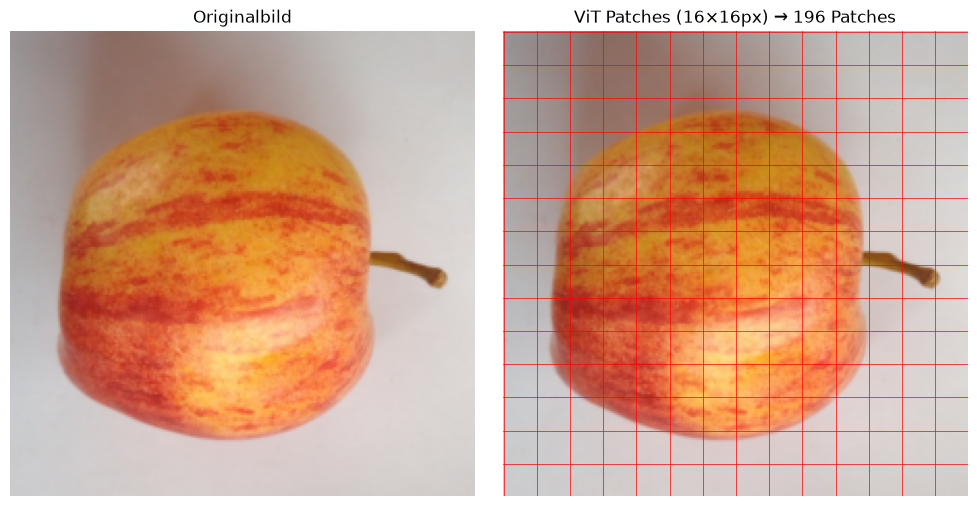

In [6]:
# Ein Bild ohne Normalisierung laden
raw_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])
sample_pil, _ = full_dataset_pil[0]
sample_tensor = raw_transform(sample_pil)
sample_np     = sample_tensor.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_np); axes[0].set_title("Originalbild"); axes[0].axis("off")
axes[1].imshow(sample_np)
for i in range(0, IMG_SIZE, PATCH_SIZE):
    axes[1].axhline(i, color="red", linewidth=0.5)
    axes[1].axvline(i, color="red", linewidth=0.5)
n_patches = (IMG_SIZE // PATCH_SIZE) ** 2
axes[1].set_title(f"ViT Patches ({PATCH_SIZE}×{PATCH_SIZE}px) → {n_patches} Patches")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("vit_patches.png", dpi=150); plt.show()

## 5. Trainings-Hilfsfunktionen

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Eine Trainingsepoche."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        # HuggingFace gibt SequenceClassifierOutput zurück → .logits
        logits  = outputs.logits if hasattr(outputs, "logits") else outputs
        loss    = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluation auf Val/Test-Set."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            logits  = outputs.logits if hasattr(outputs, "logits") else outputs
            loss    = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


def plot_history(train_accs, val_accs, train_losses, val_losses, title="Training", split_at=None):
    """Trainingsverlauf visualisieren."""
    epochs = range(1, len(train_accs) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)

    ax1.plot(epochs, train_accs, label="Train Accuracy")
    ax1.plot(epochs, val_accs,   label="Val Accuracy")
    if split_at:
        ax1.axvline(split_at, color="gray", linestyle="--", label="Fine-Tuning Start")
    ax1.set_title("Accuracy"); ax1.legend(); ax1.set_xlabel("Epoch")

    ax2.plot(epochs, train_losses, label="Train Loss")
    ax2.plot(epochs, val_losses,   label="Val Loss")
    if split_at:
        ax2.axvline(split_at, color="gray", linestyle="--", label="Fine-Tuning Start")
    ax2.set_title("Loss"); ax2.legend(); ax2.set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig(title.lower().replace(" ", "_") + "_history.png", dpi=150)
    plt.show()


def get_predictions(model, loader):
    """Alle Vorhersagen für Confusion Matrix sammeln."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            logits  = outputs.logits if hasattr(outputs, "logits") else outputs
            y_true.extend(labels.numpy())
            y_pred.extend(logits.argmax(1).cpu().numpy())
    return np.array(y_true), np.array(y_pred)


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Confusion Matrix visualisieren."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.savefig(title.lower().replace(" ", "_").replace("–","") + ".png", dpi=150)
    plt.show()

---
# Teil A: Pretrained ViT (HuggingFace `google/vit-base-patch16-224-in21k`)

Vortrainiert auf **ImageNet-21k** – native PyTorch-Version
**Zwei Phasen:**
- **Phase 1** – ViT eingefroren, nur Classification-Head trainieren
- **Phase 2** – Letzte 3 Transformer-Blöcke auftauen (Fine-Tuning)

## 6. Pretrained ViT – Modell laden

In [9]:
HF_MODEL = "google/vit-base-patch16-224-in21k"

# Modell laden und Head für unsere Klassen anpassen
pt_model = ViTForImageClassification.from_pretrained(
    HF_MODEL,
    num_labels=num_classes,
    ignore_mismatched_sizes=True,   # Head-Größe anpassen
    id2label={i: c for i, c in enumerate(class_names)},
    label2id={c: i for i, c in enumerate(class_names)},
)

# Phase 1: Alle Encoder-Blöcke einfrieren, nur Head trainierbar
for param in pt_model.vit.parameters():
    param.requires_grad = False
for param in pt_model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in pt_model.parameters())
print(f"Modell geladen: {HF_MODEL}")
print(f"Trainierbare Parameter: {trainable:,} von {total:,}")
pt_model = pt_model.to(DEVICE)

Loading weights: 100%|██████████| 6/6 [00:00<00:00, 18600.02it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.wei

Modell geladen: google/vit-base-patch16-224-in21k
Trainierbare Parameter: 1,538 von 85,800,194


## 7. Pretrained ViT – Phase 1: Transfer Learning (nur Head)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer_pt1 = optim.Adam(
    filter(lambda p: p.requires_grad, pt_model.parameters()),
    lr=PT_LR_HEAD
)
scheduler_pt1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_pt1, mode="min", factor=0.5, patience=2
)

pt_train_accs, pt_val_accs = [], []
pt_train_losses, pt_val_losses = [], []
best_val_loss = float("inf")
patience_counter = 0
PATIENCE = 4

print("=== Phase 1: Transfer Learning ===")
for epoch in range(PT_EPOCHS_HEAD):
    train_loss, train_acc = train_one_epoch(pt_model, train_loader, optimizer_pt1, criterion)
    val_loss,   val_acc   = evaluate(pt_model, val_loader, criterion)
    scheduler_pt1.step(val_loss)

    pt_train_accs.append(train_acc);   pt_val_accs.append(val_acc)
    pt_train_losses.append(train_loss); pt_val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{PT_EPOCHS_HEAD} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pt_model.state_dict(), PT_MODEL_PATH)
        print(f"  ✅ Modell gespeichert (Val Loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early Stopping nach Epoch {epoch+1}")
            break

pt_split_at = len(pt_train_accs)  # Merken für Verlaufsplot

=== Phase 1: Transfer Learning ===
Epoch 01/5 | Train Loss: 0.5785 Acc: 0.7284 | Val Loss: 0.4919 Acc: 0.8216
  ✅ Modell gespeichert (Val Loss: 0.4919)
Epoch 02/5 | Train Loss: 0.4611 Acc: 0.8256 | Val Loss: 0.4314 Acc: 0.8301
  ✅ Modell gespeichert (Val Loss: 0.4314)
Epoch 03/5 | Train Loss: 0.4147 Acc: 0.8322 | Val Loss: 0.3853 Acc: 0.8525
  ✅ Modell gespeichert (Val Loss: 0.3853)
Epoch 04/5 | Train Loss: 0.3884 Acc: 0.8424 | Val Loss: 0.3822 Acc: 0.8483
  ✅ Modell gespeichert (Val Loss: 0.3822)
Epoch 05/5 | Train Loss: 0.3739 Acc: 0.8436 | Val Loss: 0.3507 Acc: 0.8581
  ✅ Modell gespeichert (Val Loss: 0.3507)


## 8. Pretrained ViT – Phase 2: Fine-Tuning

In [11]:
# Letzte 3 Transformer-Blöcke auftauen (Blöcke 9, 10, 11)
for i, block in enumerate(pt_model.vit.layers):
    for param in block.parameters():
        param.requires_grad = (i >= 9)

trainable = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f"Fine-Tuning: {trainable:,} trainierbare Parameter")

# Bestes Modell aus Phase 1 laden
pt_model.load_state_dict(torch.load(PT_MODEL_PATH, map_location=DEVICE))

optimizer_pt2 = optim.Adam(
    filter(lambda p: p.requires_grad, pt_model.parameters()),
    lr=PT_LR_FINETUNE
)

best_val_loss    = float("inf")
patience_counter = 0
PATIENCE         = 5

print("=== Phase 2: Fine-Tuning ===")
for epoch in range(PT_EPOCHS_FINETUNE):
    train_loss, train_acc = train_one_epoch(pt_model, train_loader, optimizer_pt2, criterion)
    val_loss,   val_acc   = evaluate(pt_model, val_loader, criterion)

    pt_train_accs.append(train_acc);   pt_val_accs.append(val_acc)
    pt_train_losses.append(train_loss); pt_val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{PT_EPOCHS_FINETUNE} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pt_model.state_dict(), PT_MODEL_PATH)
        print(f"  ✅ Modell gespeichert (Val Loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early Stopping nach Epoch {epoch+1}")
            break

Fine-Tuning: 21,265,154 trainierbare Parameter
=== Phase 2: Fine-Tuning ===
Epoch 01/5 | Train Loss: 0.3324 Acc: 0.8635 | Val Loss: 0.2833 Acc: 0.8834
  ✅ Modell gespeichert (Val Loss: 0.2833)
Epoch 02/5 | Train Loss: 0.2622 Acc: 0.8881 | Val Loss: 0.2240 Acc: 0.9031
  ✅ Modell gespeichert (Val Loss: 0.2240)
Epoch 03/5 | Train Loss: 0.1938 Acc: 0.9152 | Val Loss: 0.1732 Acc: 0.9284
  ✅ Modell gespeichert (Val Loss: 0.1732)
Epoch 04/5 | Train Loss: 0.1524 Acc: 0.9374 | Val Loss: 0.2041 Acc: 0.9213
Epoch 05/5 | Train Loss: 0.1494 Acc: 0.9350 | Val Loss: 0.1727 Acc: 0.9213
  ✅ Modell gespeichert (Val Loss: 0.1727)


## 9. Pretrained ViT – Trainingsverlauf & Evaluation

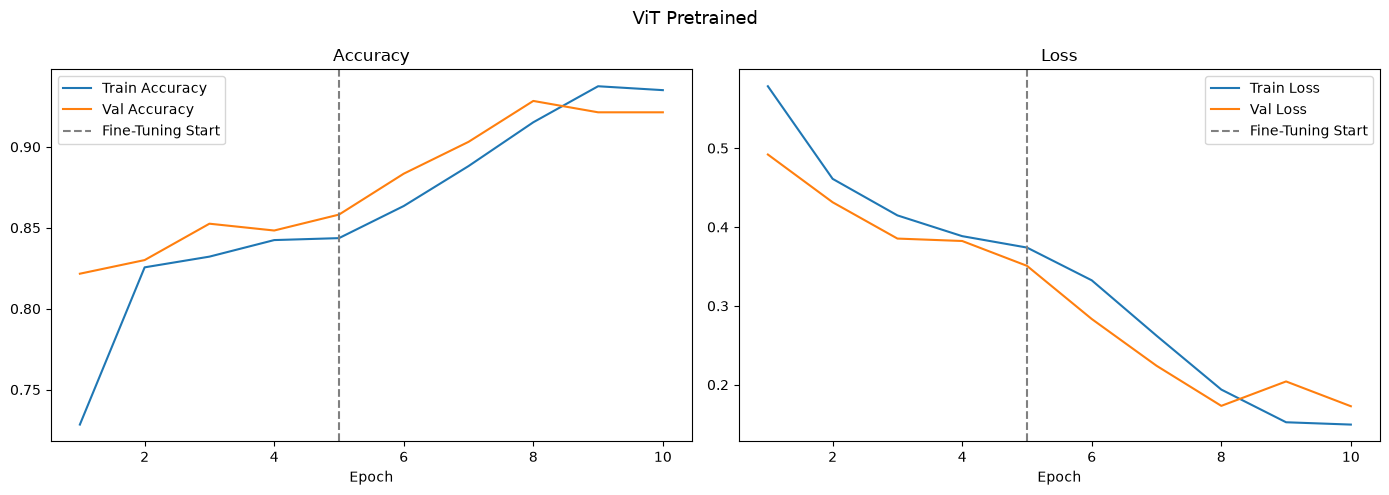

In [12]:
plot_history(pt_train_accs, pt_val_accs, pt_train_losses, pt_val_losses,
            title="ViT Pretrained", split_at=pt_split_at)

=== Pretrained ViT – Test-Set Evaluation ===
Test Accuracy: 0.9132
Test Loss:     0.1929

                precision    recall  f1-score   support

Apple__Healthy       0.84      0.97      0.90       288
 Apple__Rotten       0.98      0.87      0.92       426

      accuracy                           0.91       714
     macro avg       0.91      0.92      0.91       714
  weighted avg       0.92      0.91      0.91       714



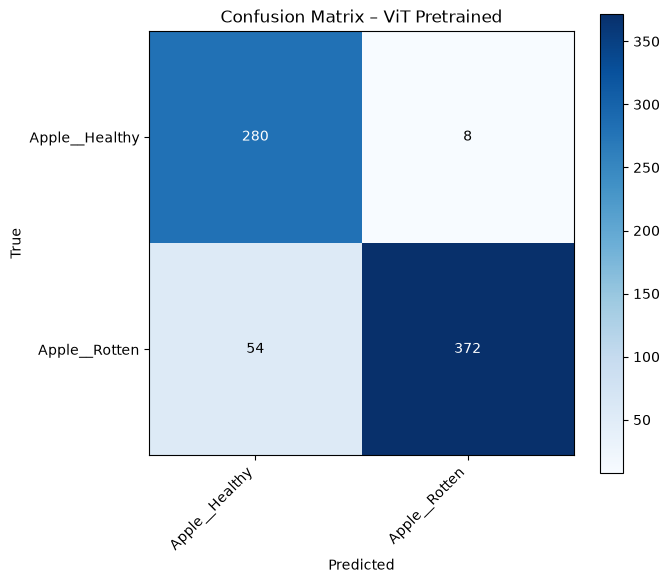

In [13]:
# Bestes Modell laden & evaluieren
pt_model.load_state_dict(torch.load(PT_MODEL_PATH, map_location=DEVICE))

pt_test_loss, pt_test_acc = evaluate(pt_model, test_loader, criterion)
print(f"=== Pretrained ViT – Test-Set Evaluation ===")
print(f"Test Accuracy: {pt_test_acc:.4f}")
print(f"Test Loss:     {pt_test_loss:.4f}\n")

y_true_pt, y_pred_pt = get_predictions(pt_model, test_loader)
print(classification_report(y_true_pt, y_pred_pt, target_names=class_names))
plot_confusion_matrix(y_true_pt, y_pred_pt, class_names, "Confusion Matrix – ViT Pretrained")

---
# Teil B: ViT From Scratch (PyTorch)

Vollständige Implementierung der **ViT-B/16 Architektur** in PyTorch.  
Alle Gewichte werden zufällig initialisiert – kein Vorwissen aus ImageNet.

## 10. ViT From Scratch – Architektur implementieren

In [14]:
class PatchEmbedding(nn.Module):
    """Bild → Patches → Linear Projection."""
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # Conv2d als effizienter Patch-Extraktor
        self.projection  = nn.Conv2d(in_channels, embed_dim,
                                     kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.projection(x)          # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)                # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)          # (B, num_patches, embed_dim)
        return x


class ViTScratch(nn.Module):
    """Vision Transformer (ViT-B/16) from Scratch in PyTorch."""
    def __init__(self, img_size, patch_size, num_classes, embed_dim,
                 num_heads, num_layers, mlp_dim, dropout):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2

        # Patch Embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)

        # [CLS]-Token & Positional Encoding (lernbar)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=mlp_dim, dropout=dropout,
            activation="gelu", batch_first=True, norm_first=True,  # Pre-LN
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # MLP Head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim // 3),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(mlp_dim // 3, mlp_dim // 6),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(mlp_dim // 6, num_classes),
        )

        # Gewichte initialisieren
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                               # (B, N, D)

        cls = self.cls_token.expand(B, -1, -1)               # (B, 1, D)
        x   = torch.cat([cls, x], dim=1)                     # (B, N+1, D)
        x   = self.pos_drop(x + self.pos_embed)

        x   = self.transformer(x)                            # (B, N+1, D)
        x   = self.norm(x[:, 0])                             # [CLS]-Token
        return self.head(x)


sc_model = ViTScratch(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE,
    num_classes=num_classes, embed_dim=PROJECTION_DIM,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    mlp_dim=MLP_DIM, dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in sc_model.parameters())
print(f"ViT From Scratch: {total_params:,} Parameter")

ViT From Scratch: 87,111,938 Parameter


C:\Users\Hendrik\AppData\Local\Temp\ipykernel_137220\1268626967.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## 11. ViT From Scratch – Training

**Cosine Annealing** + **AdamW**

In [15]:
optimizer_sc = optim.AdamW(sc_model.parameters(), lr=SC_LR, weight_decay=1e-4)
scheduler_sc = optim.lr_scheduler.CosineAnnealingLR(optimizer_sc, T_max=SC_EPOCHS, eta_min=1e-6)

sc_train_accs, sc_val_accs     = [], []
sc_train_losses, sc_val_losses = [], []
best_val_loss    = float("inf")
patience_counter = 0
PATIENCE         = 8

print("=== ViT From Scratch Training ===")
for epoch in range(SC_EPOCHS):
    train_loss, train_acc = train_one_epoch(sc_model, train_loader, optimizer_sc, criterion)
    val_loss,   val_acc   = evaluate(sc_model, val_loader, criterion)
    scheduler_sc.step()

    sc_train_accs.append(train_acc);    sc_val_accs.append(val_acc)
    sc_train_losses.append(train_loss); sc_val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{SC_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(sc_model.state_dict(), SC_MODEL_PATH)
        print(f"  ✅ Modell gespeichert (Val Loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early Stopping nach Epoch {epoch+1}")
            break

=== ViT From Scratch Training ===
Epoch 01/30 | Train Loss: 0.7066 Acc: 0.5534 | Val Loss: 0.6709 Acc: 0.6067
  ✅ Modell gespeichert (Val Loss: 0.6709)
Epoch 02/30 | Train Loss: 0.6865 Acc: 0.5684 | Val Loss: 0.6852 Acc: 0.6067
Epoch 03/30 | Train Loss: 0.6863 Acc: 0.5630 | Val Loss: 0.6792 Acc: 0.6067
Epoch 04/30 | Train Loss: 0.6879 Acc: 0.5639 | Val Loss: 0.6756 Acc: 0.6067
Epoch 05/30 | Train Loss: 0.6853 Acc: 0.5729 | Val Loss: 0.6731 Acc: 0.6067
Epoch 06/30 | Train Loss: 0.6844 Acc: 0.5678 | Val Loss: 0.6632 Acc: 0.6067
  ✅ Modell gespeichert (Val Loss: 0.6632)


KeyboardInterrupt: 

## 12. ViT From Scratch – Trainingsverlauf & Evaluation

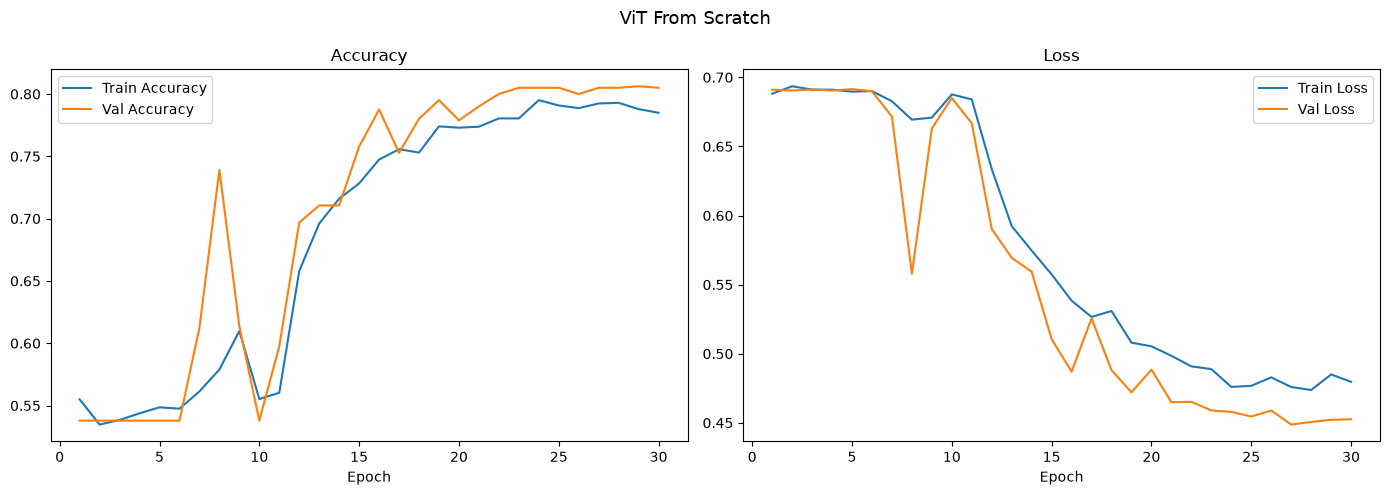

In [24]:
plot_history(sc_train_accs, sc_val_accs, sc_train_losses, sc_val_losses,
            title="ViT From Scratch")

=== ViT From Scratch – Test-Set Evaluation ===
Test Accuracy: 0.7717
Test Loss:     0.5165

                precision    recall  f1-score   support

Apple__Healthy       0.88      0.58      0.70       370
 Apple__Rotten       0.72      0.94      0.82       436

      accuracy                           0.77       806
     macro avg       0.80      0.76      0.76       806
  weighted avg       0.80      0.77      0.76       806



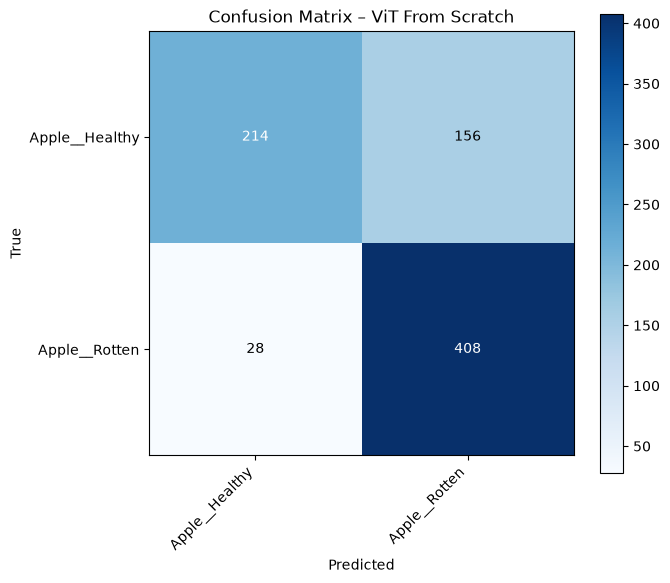

In [25]:
sc_model.load_state_dict(torch.load(SC_MODEL_PATH, map_location=DEVICE))

sc_test_loss, sc_test_acc = evaluate(sc_model, test_loader, criterion)
print(f"=== ViT From Scratch – Test-Set Evaluation ===")
print(f"Test Accuracy: {sc_test_acc:.4f}")
print(f"Test Loss:     {sc_test_loss:.4f}\n")

y_true_sc, y_pred_sc = get_predictions(sc_model, test_loader)
print(classification_report(y_true_sc, y_pred_sc, target_names=class_names))
plot_confusion_matrix(y_true_sc, y_pred_sc, class_names, "Confusion Matrix – ViT From Scratch")

---
## 13. Finaler Modellvergleich (nicht aktualisiert)

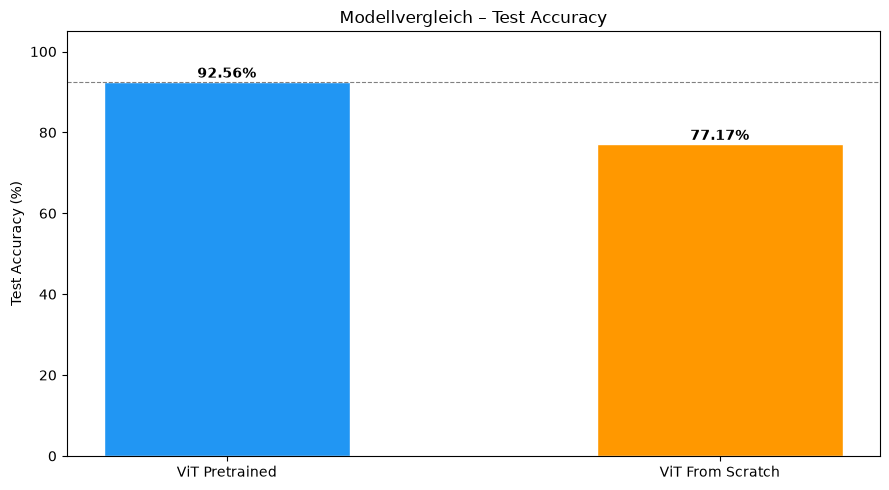


=== Zusammenfassung ===
  ViT Pretrained            Accuracy: 0.9256 (92.56%)
  ViT From Scratch          Accuracy: 0.7717 (77.17%)


In [26]:
# MobileNetV2-Ergebnis optional eintragen (aus dem TF-Notebook)
mobilenet_acc = None   # z.B. 0.9421

results = {
    "ViT Pretrained":   pt_test_acc,
    "ViT From Scratch": sc_test_acc,
}
if mobilenet_acc:
    results["MobileNetV2 (Transfer)"] = mobilenet_acc

names      = list(results.keys())
accuracies = [v * 100 for v in results.values()]
colors     = ["#2196F3", "#FF9800", "#4CAF50"][:len(results)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, accuracies, color=colors, width=0.5, edgecolor="white")
ax.set_ylabel("Test Accuracy (%)"); ax.set_ylim(0, 105)
ax.set_title("Modellvergleich – Test Accuracy")
ax.axhline(max(accuracies), color="gray", linestyle="--", linewidth=0.8)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{acc:.2f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150); plt.show()

print("\n=== Zusammenfassung ===")
for name, acc in results.items():
    print(f"  {name:<25} Accuracy: {acc:.4f} ({acc*100:.2f}%)")

## 14. Einzelbild-Inferenz

In [27]:
from PIL import Image

best_model = pt_model if pt_test_acc >= sc_test_acc else sc_model
best_name  = "ViT Pretrained" if pt_test_acc >= sc_test_acc else "ViT From Scratch"
print(f"Bestes Modell: {best_name}")

def predict_single_image(image_path: str):
    """Klassifiziert ein einzelnes Bild mit dem besten ViT-Modell."""
    img    = Image.open(image_path).convert("RGB")
    tensor = val_transform(img).unsqueeze(0).to(DEVICE)

    best_model.eval()
    with torch.no_grad():
        output = best_model(tensor)
        logits = output.logits if hasattr(output, "logits") else output
        probs  = torch.softmax(logits, dim=1)[0]

    pred_idx        = probs.argmax().item()
    predicted_class = class_names[pred_idx]
    confidence      = probs[pred_idx].item()

    print(f"Modell:      {best_name}")
    print(f"Klasse:      {predicted_class}")
    print(f"Konfidenz:   {confidence:.2%}")
    print(f"Alle Scores: { {c: f'{p:.2%}' for c, p in zip(class_names, probs.cpu().numpy())} }")
    return predicted_class, confidence

# Beispielaufruf:
# predict_single_image("pfad/zum/bild.jpg")

Bestes Modell: ViT Pretrained


In [10]:
torch.save(pt_model.state_dict(), "tmp_pt.pth")
torch.save(sc_model.state_dict(), "tmp_sc.pth")

models = {
    "ViT Pretrained":   (pt_model, "tmp_pt.pth"),
    "ViT From Scratch": (sc_model, "tmp_sc.pth"),
}

In [ ]:
import time, os
import numpy as np

# ── Speicher ──────────────────────────────────────────────────────────────────
def model_size_mb(model):
    """Speicher der Gewichte im RAM/VRAM (Parameter + Buffer)."""
    p = sum(t.numel() * t.element_size() for t in model.parameters())
    b = sum(t.numel() * t.element_size() for t in model.buffers())
    return (p + b) / 1024**2

def file_size_mb(path):
    """Größe der gespeicherten .pth-Datei auf der Festplatte."""
    return os.path.getsize(path) / 1024**2

@torch.inference_mode()
def activation_mem_mb(model, batch_size=1):
    """Zusätzlicher GPU-Speicher während eines Forward-Pass (nur CUDA)."""
    if DEVICE.type != "cuda":
        return float("nan")
    model.eval()
    x = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    baseline = torch.cuda.memory_allocated()
    model(x)
    torch.cuda.synchronize()
    return (torch.cuda.max_memory_allocated() - baseline) / 1024**2

# ── Laufzeit ──────────────────────────────────────────────────────────────────
@torch.inference_mode()
def latency_ms(model, batch_size=1, n_warmup=10, n_runs=100):
    """Median und 95. Perzentil der Inferenzzeit pro Bild in ms."""
    model.eval()
    x = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    for _ in range(n_warmup):            # Aufwärmen (CUDA-Init, Kernel-Auswahl, Caches)
        model(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model(x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()     # GPU arbeitet asynchron
        times.append((time.perf_counter() - t0) * 1000 / batch_size)
    return np.median(times), np.percentile(times, 95)

# ── Messen ────────────────────────────────────────────────────────────────────
torch.save(pt_model.state_dict(), "tmp_pt.pth")
torch.save(sc_model.state_dict(), "tmp_sc.pth")

models = {
    "ViT Pretrained":   (pt_model, "tmp_pt.pth"),
    "ViT From Scratch": (sc_model, "tmp_sc.pth"),
}

print(f"Device: {DEVICE}\n")
print(f"{'Modell':<18} {'Params':>8} {'RAM (MB)':>9} {'Datei (MB)':>11} "
      f"{'Akt. (MB)':>10} {'ms/Bild bs=1':>13} {'p95':>7} {'ms/Bild bs=32':>14}")
for name, (m, path) in models.items():
    n_params  = sum(p.numel() for p in m.parameters()) / 1e6
    lat1, p95 = latency_ms(m, batch_size=1, n_warmup=5, n_runs=50)
    lat32, _  = latency_ms(m, batch_size=BATCH_SIZE, n_warmup=2, n_runs=5)
    print(f"{name:<18} {n_params:>7.1f}M {model_size_mb(m):>9.1f} {file_size_mb(path):>11.1f} "
          f"{activation_mem_mb(m):>10.1f} {lat1:>13.2f} {p95:>7.2f} {lat32:>14.2f}")

Device: cpu

Modell               Params  RAM (MB)  Datei (MB)  Akt. (MB)  ms/Bild bs=1     p95  ms/Bild bs=32
ViT Pretrained        85.8M     327.3       327.4        nan        100.92  108.62          81.01
ViT From Scratch      87.1M     332.3       332.4        nan        100.15  105.73          82.35
